# Лабораторна робота 3. Криптографiчнi хеш функцiї

## Л3.1 Реалiзуйте криптографiчну хеш функцiю SHA-256.

In [1]:
def rotr(x, n):
    """Циклічний зсув вправо (right rotate) на n позицій для 32-бітного числа"""
    # 1. Зсуваємо вправо (частина бітів випадає)
    right_part = x >> n
    # 2. Зсуваємо вліво
    # 0xFFFFFFFF - шістнадцяткове представлення числа, яке складається з 32 одиниць у двійковій системі (2^32 - 1)
    left_part = (x << (32 - n)) & 0xFFFFFFFF
    # 3. Об'єднуємо їх
    result = right_part | left_part
    return result

def shr(x, n):
    """Логічний зсув вправо (shift right) на n позицій"""
    return x >> n

def Sum0(x):
    # Σ0(x) = (x ⋙ 2) ⊕ (x ⋙ 13) ⊕ (x ⋙ 22) 
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sum1(x):
    # Σ1(x) = (x ⋙ 6) ⊕ (x ⋙ 11) ⊕ (x ⋙ 25) 
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x):
    # σ0(x) = (x ⋙ 7) ⊕ (x ⋙ 18) ⊕ (x ≫ 3)
    # останній операнд це звичайний зсув (shift), не циклічний
    return rotr(x, 7) ^ rotr(x, 18) ^ shr(x, 3)

def sigma1(x):
    # σ1(x) = (x ⋙ 17) ⊕ (x ⋙ 19) ⊕ (x ≫ 10) 
    # останній операнд це звичайний зсув (shift), не циклічний
    return rotr(x, 17) ^ rotr(x, 19) ^ shr(x, 10) 


def f_prime(u, v, w):
    # f'(u,v,w) = (u ∧ v) ⊕ (¬u ∧ w) [cite: 82]
    # & - побітове "та"
    # ^ - побітове "або"
    # ~ - побітове "не"
    return (u & v) ^ ((~u) & w)

def g_prime(u, v, w):
    # g'(u,v,w) = (u ∧ v) ⊕ (u ∧ w) ⊕ (v ∧ w) [cite: 82]
    return (u & v) ^ (u & w) ^ (v & w)

K = [
    0x428a2f98, 0x71374491, 0xb5c0fbcf, 0xe9b5dba5, 0x3956c25b, 0x59f111f1, 0x923f82a4, 0xab1c5ed5,
    0xd807aa98, 0x12835b01, 0x243185be, 0x550c7dc3, 0x72be5d74, 0x80deb1fe, 0x9bdc06a7, 0xc19bf174,
    0xe49b69c1, 0xefbe4786, 0x0fc19dc6, 0x240ca1cc, 0x2de92c6f, 0x4a7484aa, 0x5cb0a9dc, 0x76f988da,
    0x983e5152, 0xa831c66d, 0xb00327c8, 0xbf597fc7, 0xc6e00bf3, 0xd5a79147, 0x06ca6351, 0x14292967,
    0x27b70a85, 0x2e1b2138, 0x4d2c6dfc, 0x53380d13, 0x650a7354, 0x766a0abb, 0x81c2c92e, 0x92722c85,
    0xa2bfe8a1, 0xa81a664b, 0xc24b8b70, 0xc76c51a3, 0xd192e819, 0xd6990624, 0xf40e3585, 0x106aa070,
    0x19a4c116, 0x1e376c08, 0x2748774c, 0x34b0bcb5, 0x391c0cb3, 0x4ed8aa4a, 0x5b9cca4f, 0x682e6ff3,
    0x748f82ee, 0x78a5636f, 0x84c87814, 0x8cc70208, 0x90befffa, 0xa4506ceb, 0xbef9a3f7, 0xc67178f2
]
    
def sha256(message_bytes: bytes):
    # Початкові значення H0...H7
    H = [0x6A09E667, 0xBB67AE85, 0x3C6EF372, 0xA54FF53A,
         0x510E527F, 0x9B05688C, 0x1F83D9AB, 0x5BE0CD19]
    
    l = len(message_bytes) * 8 # довжина в бітах 
    msg = bytearray(message_bytes)
    msg.append(0x80) # додаємо '1'
    
    # Додаємо v нулів, щоб довжина була кратна 512 мінус 64 біти 
    while (len(msg) * 8) % 512 != 448:
            msg.append(0x00)
        
    # Додаємо 64-бітне представлення l 
    msg += l.to_bytes(8, byteorder='big')

    for i in range(0, len(msg), 64):
        block = msg[i:i+64]
        # Розбиваємо блок на 16 слів Xj 
        X = []
        for j in range(0, 64, 4):
            word = int.from_bytes(block[j:j+4], byteorder='big')
            X.append(word)
        # Expansion: розширюємо до 64 слів
        for j in range(16, 64):
            # Xi = σ1(Xi-2) + Xi-7 + σ0(Xi-15) + Xi-16 
            val = (sigma1(X[j-2]) + X[j-7] + sigma0(X[j-15]) + X[j-16]) & 0xFFFFFFFF
            X.append(val)
        a, b, c, d, e, f, g, h = H
        # 64 раунди стиснення 
        for j in range(64):
            # t1 = H + Σ1(E) + f'(E,F,G) + Ki + Xi 
            t1 = (h + Sum1(e) + f_prime(e, f, g) + K[j] + X[j]) & 0xFFFFFFFF
            # t2 = Σ0(A) + g'(A,B,C) [cite: 113]
            t2 = (Sum0(a) + g_prime(a, b, c)) & 0xFFFFFFFF
            # (A,B,C,D,E,F,G,H) <- (t1+t2, A, B, C, D+t1, E, F, G) 
            a, b, c, d, e, f, g, h = (t1 + t2) & 0xFFFFFFFF, a, b, c, (d + t1) & 0xFFFFFFFF, e, f, g
        round_results = [a, b, c, d, e, f, g, h]
        for j in range(8):
            H[j] = (H[j] + round_results[j]) & 0xFFFFFFFF
            
    # Результат - конкатенація фінальних значень H0...H7
    return ''.join(f'{val:08x}' for val in H)

print(sha256(b"The quick brown fox jumps over the lazy dog"))

d7a8fbb307d7809469ca9abcb0082e4f8d5651e46d3cdb762d02d0bf37c9e592


## Л3.2 Продемонструйте лавинний ефект на прикладi 10 рiзних панграм для українського алфавiту.

Демонстрація лавинного ефекту.

Панграма №1: змінено 115 бітів
  [Original]: 1b31fddcfe30f3c111ba44291495626ca39bac75ade5e69b0effadf525010bb0
  [Modified]: 05812b9e7e6cd9a8e81284b92c1ab9b6b4350ec99060a68e5fb30c55eed24f6c
--------------------------------------------------------------------------------
Панграма №2: змінено 147 бітів
  [Original]: 6ac6addbc0d71872edac7a19655cbf4dd8423df4fd5486b5ab94acf15cce6577
  [Modified]: 5d9a414c02aa509d363fa1619b62f4799e96a5afe0af18455ee3045439a7b930
--------------------------------------------------------------------------------
Панграма №3: змінено 120 бітів
  [Original]: 8cbdc4cf25a99fe873d9309319752d7ecd4e5f211ef46cac8a6eab3e6ffb9a5b
  [Modified]: f76acc399de8f3bcae8fdf14384829e24800d3a02e3208221ffe0d66d44c5ecb
--------------------------------------------------------------------------------
Панграма №4: змінено 140 бітів
  [Original]: 6843fb6cacf87b6c20b82004e6aadd354ec655a6158e0d298f457d57b493d349
  [Modified]: d15d21ed648dad18438b8de347271b1201

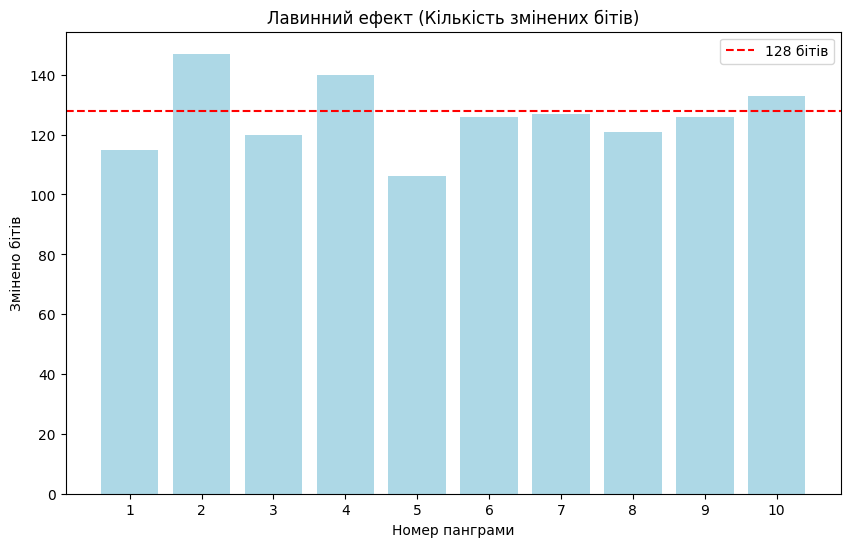

In [2]:
import matplotlib.pyplot as plt

pangrams = [
    "Щастям б'єш жук їх глицю в фон й ґедзь пріч.",
    "Факт ґринджол: бій псюг вщух, з'їм шче яєць.",
    "З'їв аґрусу — та ягода цілюща б'є жах інфекцій шипучим „ь“.",
    "Ґедзь же пояснює: годі! з'їв ще б чашу джему й цілих фруктів",
    "Фабрикуймо гідність, лящім їжею, ґав хапаймо, з'єднавці чаш!",
    "Юнкерський джинґл, що при безхліб'ї чує фашист, це ловця гімн.",
    "Хвацький юшковар Філіп щодня на ґанку готує сім'ї вечерю з жаб.",
    "В Бахчисараї фельд'єґер зумів одягнути ящірці жовтий капюшон!",
    "На подушечці форми любої є й ґудзик, щоб пір'я геть жовте сховати.",
    "Щурячий бугай із їжаком-харцизом в'ючись підписали ґешефт у єнах."
]
res = []
print("Демонстрація лавинного ефекту.\n")

for i, text in enumerate(pangrams, 1):
    # Отримуємо хеші (hex-рядки) у вигляді string
    h1_hex = sha256(text.encode('utf-8'))
    h2_hex = sha256((text[:-1] + "я").encode('utf-8'))

    # 1. Перетворюємо hex-рядки у великі числа
    val1 = int(h1_hex, 16)
    val2 = int(h2_hex, 16)
    # 2. Робимо XOR (видає одиницю, тільки якщо біти різні)
    diff = val1 ^ val2
    # 3. Перетворює число у бінарний рядок та рахує скільки разів зустрічається "1", 
    # а кожна одиниця в результаті XOR означає один біт, який змінився внаслідок лавинного ефекту 
    diff_bits = bin(diff).count('1')
    res.append(diff_bits)
    print(f"Панграма №{i}: змінено {diff_bits} бітів")
    print(f"  [Original]: {h1_hex}")
    print(f"  [Modified]: {h2_hex}")
    print("-" * 80)

plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), res, color='lightblue')
plt.axhline(y=128, color='red', linestyle='--', label='128 бітів')
plt.title('Лавинний ефект (Кількість змінених бітів)')
plt.xlabel('Номер панграми')
plt.ylabel('Змінено бітів')
plt.xticks(range(1, 11))
plt.legend()
plt.show()

## Висновок: 
Навіть мінімальна зміна одного символу в тексті призводить до того, що хеш змінюється майже наполовину (в середньому на 128 бітів), що чудово видно на графіку. Жодної схожості між оригінальним і зміненим хешем немає — вони виглядають як абсолютно різні випадкові набори символів. Це підтверджує, що функція працює правильно і надійно приховує зв'язок між вхідними даними та результатом.

## Л3.3 Реалiзуйте алгоритм пошуку часткових колiзiй. Складiть таблицi середнього часу (для 100 спроб) знаходження часткової колiзiї для k перших бiтiв хеш суми, 5 ≤ k ≤ 15.

**Колізія** — це ситуація, коли два **різних** вхідних повідомлення ($m_1 \neq m_2$) мають однакове значення хеш-функції: $h(m_1) = h(m_2)$.
**Часткова колізія** - це ситуація, коли у двох різних повідомлень збігаються лише перші $k$ бітів хеш-суми.

k (бітів)  | Сер. час (100 спроб), сек
----------------------------------------
5          | 0.001037
6          | 0.004851
7          | 0.024591
8          | 0.024457
9          | 0.068337
10         | 0.068547
11         | 0.069090
12         | 0.269063
13         | 1.318887
14         | 3.111997
15         | 5.431985


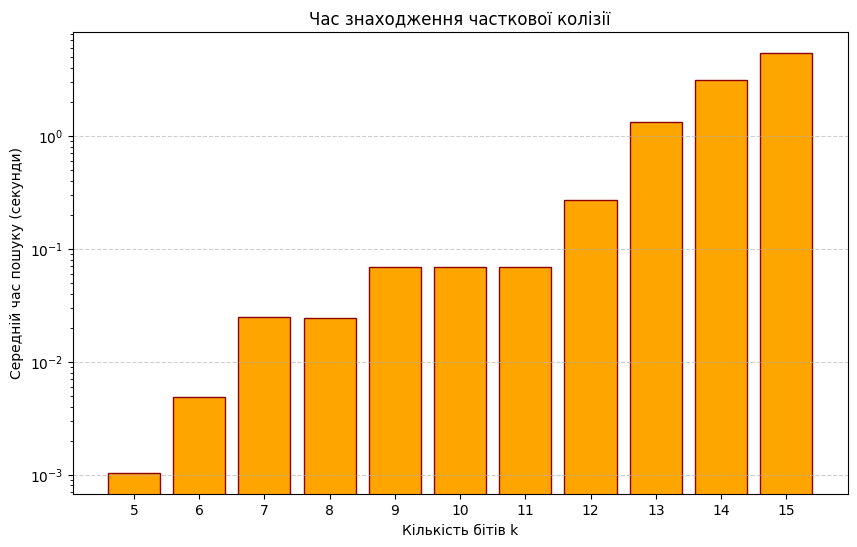

In [3]:
import time
import matplotlib.pyplot as plt

def get_k_bits(hex_str, k):
    """Виділяє перші k бітів із шістнадцяткового рядка"""
    full_int = int(hex_str, 16)
    # повний хеш SHA-256 має 256 бітів, а нам потрібні перші k (зліва), ми відкидаємо непотрібні (256−k) бітів справа
    return full_int >> (256 - k)

def run_collision_test():
    print(f"{'k (бітів)':<10} | {'Сер. час (100 спроб), сек'}")
    print("-" * 40)
    hash_word = sha256(b"cryptography")
    
    k_values = []
    average_times = []
    
    for k in range(5, 16):
        bits_word = get_k_bits(hash_word, k)
        total_time = 0
        
        for _ in range(100): 
            start = time.time()
            counter = 0
            while True:
                input_variant = str(counter).encode('utf-8')
                input_variant_hash = sha256(input_variant)
                # Перевіряємо, чи збігаються перші k бітів
                if get_k_bits(input_variant_hash, k) == bits_word:
                    break
                counter += 1
            total_time += (time.time() - start)   
            
        avg_time = total_time / 100
        k_values.append(k)
        average_times.append(avg_time)
        print(f"{k:<10} | {avg_time:.6f}")

    plt.figure(figsize=(10, 6))
    plt.bar(k_values, average_times, color='orange', edgecolor='darkred')
    plt.xlabel('Кількість бітів k')
    plt.ylabel('Середній час пошуку (секунди)')
    plt.title('Час знаходження часткової колізії')
    plt.xticks(k_values)
    plt.yscale('log') 
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

run_collision_test()

Графік показує, що зі збільшенням кількості бітів складність пошуку колізії зростає дуже швидко. Кожен додатковий біт приблизно вдвічі збільшує час, необхідний для знаходження збігу. Це підтверджує, що підібрати навіть частину хешу вкрай важко, а знайти повну колізію для всього захищеного коду практично неможливо.